
---

# 论文笔记：《DiffusionNFT: Online Diffusion Reinforcement with Forward Process》

论文提出了 **DiffusionNFT** 框架，首次实现了在前向加噪过程（Forward Process）中完成扩散控制策略的在线强化学习（RL），摆脱了传统方法依赖反向采样链的诸多限制。

---

## 一、 核心动机与背景：现有扩散 RL（以 FlowGRPO 为例）的底层痛点

传统的扩散/流匹配策略对齐（如 FlowGRPO、DanceGRPO）本质上是在逆向去噪过程（Reverse Process）中优化策略梯度（Policy Gradient）。为了计算路径的对数似然梯度，算法必须将确定性的 ODE 采样器转化为随机 SDE。论文开篇指出，这种传统范式存在三大难以调和的工程与数学痛点：

* **采样器严重受限（Solver Restriction）**：由于必须在马尔可夫链的每一步上精确估计路径的对数似然（Log-likelihood），训练阶段**只能绑定一阶离散的 SDE 采样器**（如 Euler-Maruyama）。这意味着无法使用 DDIM、DPM-Solver++ 或 Flow Matching 的高阶黑盒 ODE 积分器进行训练加速。
* **显存与计算代价巨大（Memory Inefficiency）**：逆向策略梯度依赖于完整的时序去噪轨迹（$t = T \to 0$）。在数据收集阶段，算法必须**将整条反向采样路径上所有时间步的高维中间状态 $x_t$ 全部缓存在显存中**以支持反向传播，显存开销随去噪步数呈线性爆炸。
* **前向-反向动力学不一致（Forward-Reverse Inconsistency）**：直接在反向离散路径上对速度场施加策略梯度拉扯，极易破坏扩散模型底层概率密度所满足的 Fokker-Planck 方程的一致性，导致多轮迭代后数据流形退化崩溃。

### 💡 DiffusionNFT 的前向解法

论文提出将强化学习的微调完全移至**前向加噪过程（Forward Process）**。在数据收集期，可以使用**任意黑盒高阶 ODE 采样器**（如 20 步 DPM-Solver++）高效采样出最终轨迹 $x_0$。在微调训练期，**只需要静态的 $x_0$ 及其对应的标量奖励 $r$**，中间的 $x_t$ 通过前向条件加噪闭式生成。这实现了采样与训练的完全解耦，显存开销从 $\mathcal{O}(T)$ 降至 $\mathcal{O}(1)$。


---

## 二、 官方叙事：Theorem 3.1 速度空间的“三点共线”与强化引导机制

在 Section 3.1 与 3.2 中，论文通过将强化学习框架映射为贝叶斯概率推理，在连续流匹配的速度空间（Velocity Space）中推导出了核心的几何定理。

### 2.1 强化学习的概率化表征与正负流形划分

论文首先采用 Levine (2018) 的强化学习概率推理框架（RL as Probabilistic Inference）。假设当前迭代的行为策略（旧策略）为 $\pi_{\text{old}}(x_0|c)$，其中 $c$ 为输入的条件提示（Prompt）。对于给定的 $c$，策略采样生成 $K$ 个样本 $\{x_0^{1:K}\}$，并由标量奖励函数 $r(x_0, c) \in [0, 1]$ 评估其表现。

为了将连续的奖励值转化为明确的策略对齐目标，论文将奖励值定义为**最优性概率（Optimality Probability）**：

$$r(x_0, c) := p(o = 1 \,|\, x_0, c)$$

其中 $o = 1$ 表示该样本属于“最优”。基于此定义，收集到的数据集被隐式地划分为两个虚拟子集：正样本集 $\mathcal{D}^+$（以概率 $r$ 划分）与负样本集 $\mathcal{D}^-$（以概率 $1-r$ 划分）。在无限样本的极限下，这两个子集的底层条件概率分布分别表示为：

* **正策略流形（Positive Mixture）**：

$$\pi^+(x_0|c) := \pi_{\text{old}}(x_0 \,|\, o = 1, c) = \frac{r(x_0, c)}{\mathbb{E}_{\pi_{\text{old}}(\cdot|c)}[r(x_0, c)]} \pi_{\text{old}}(x_0|c)$$


* **负策略流形（Negative Mixture）**：

$$\pi^-(x_0|c) := \pi_{\text{old}}(x_0 \,|\, o = 0, c) = \frac{1 - r(x_0, c)}{1 - \mathbb{E}_{\pi_{\text{old}}(\cdot|c)}[r(x_0, c)]} \pi_{\text{old}}(x_0|c)$$



显然，在策略质量的序关系上，满足恒等关系：$\pi^+ \succ \pi_{\text{old}} \succ \pi^-$。传统的拒绝微调（RFT）仅在 $\mathcal{D}^+$ 上进行扩散有监督训练，完全遗弃了 $\mathcal{D}^-$ 中的负向反馈。

为了同时利用正负反馈，论文提出在旧策略速度场 $v_{\text{old}}$ 的基础上，引入一个更新方向 $\Delta \in \mathbb{R}^n$，构建最优强化目标速度场 $v^*$：

$$v^*(x_t, c, t) := v_{\text{old}}(x_t, c, t) + \frac{1}{\beta} \Delta(x_t, c, t) \tag{3}$$

其中 $\Delta$ 被定义为**强化引导（Reinforcement Guidance）**，$\frac{1}{\beta}$ 为引导强度。该形式在数学上与 Classifier-Free Guidance (CFG) 满足高度的同构性。

---

### 2.2 Theorem 3.1（改进方向定理）的官方表述

为了确定合理的强化引导方向 $\Delta$，论文探讨了行为Triplet $\pi^+ \succ \pi_{\text{old}} \succ \pi^-$ 在前向加噪时空（$x_t, t$）中对应的连续速度场 $v^+$, $v_{\text{old}}$, $v^-$ 的分布差异。

> **Theorem 3.1 (Improvement Direction)**. 设 $v^+$, $v^-$, $v_{\text{old}}$ 分别为策略 $\pi^+$, $\pi^-$, $\pi_{\text{old}}$ 在流匹配框架下对应的连续速度场预测器。这些模型之间的方向位移呈现出严格的比例共线关系：
> 
> $$\begin{aligned} \Delta &:= [1 - \alpha(x_t)] \big[ v_{\text{old}}(x_t, c, t) - v^-(x_t, c, t) \big] \quad \text{(负向推开位移)} \\ &= \alpha(x_t) \big[ v^+(x_t, c, t) - v_{\text{old}}(x_t, c, t) \big] \quad \text{(正向拉近位移)} \end{aligned} \tag{4}$$
> 
> 
> 其中 $\alpha(x_t) \in [0, 1]$ 为前向时空中某一点的局部后验标量系数：
> 
> $$\alpha(x_t) := \frac{\pi^+_t(x_t|c)}{\pi^{\text{old}}_t(x_t|c)} \mathbb{E}_{\pi_{\text{old}}(x_0|c)}[r(x_0, c)] \equiv p(o=1 \,|\, x_t, c)$$
> 
> 

#### 官方证明传递的性质：

1. **速度凸组合（Velocity Composition）**：将公式 (4) 展开并移项，可以直接导出 $v_{\text{old}} = \alpha(x_t) v^+ + \big(1 - \alpha(x_t)\big) v^-$。这表明在任意时空坐标 $(x_t, t)$ 处，旧策略的速度场天然排布在正负极端速度场构成的凸组合线段上。
2. **保证策略提升（Guaranteed Policy Improvement）**：公式 (4) 给出了提升策略的无偏几何方向。若令公式 (3) 中的引导强度 $\beta = \alpha(x_t)$，则最优目标速度场 $v^* = v_{\text{old}} + \frac{1}{\alpha(x_t)} \Delta = v^+$，此时训练优化目标完全等价于向最优专家流形 $\pi^+$ 收敛，从而在理论上确保了 $\pi^* \succ \pi_{\text{old}}$。

---





## 三、 灵感来源与核心破局

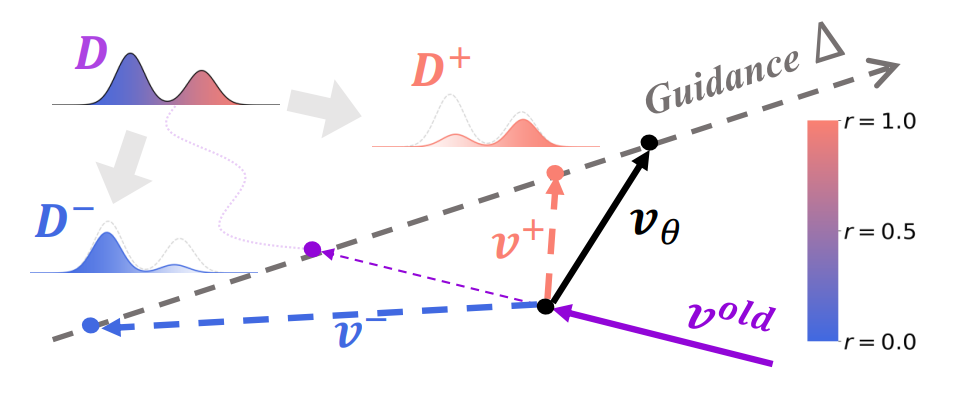

论文前半段，实际上在证明三个向量$v_{\text{old}} - v^-$、$v^+ - v_{\text{old}}$，$v^*-v_{\text{old}}$是共线，并且成一定比例，然后得到它们之间的关系之后，直接给出了$v^*$的统一表达和$\Delta$的两种表达式，意思是，通过设定引导强度，$v^*$能够得到任意的结果,就像一个滑动变阻器，可以严格等于正或负策略，也可以超越正策略，还可以比负策略更坏，这才是论文背后的灵感来源，而不是文中写的，故弄玄虚的直接给出结论，核心改进就是，在LLM的NFT里，用正策略来表达负策略，最后只留下正策略，这里的被训练的策略，能够同时表达正负策略，可以灵活的强化    

这篇论文前半段的真正动机，在于它在连续的高维速度空间中，**强行拉出了一条无界的、一维的“强化外推数轴”**。

它的核心灵感直接复刻了大语言模型（LLM）里 **NFT（负感知微调）** 的底层哲学：**丢弃多网络拉扯的臃肿架构，用一个被训练的策略去同时隐式表达正、负两种力量，最终收敛于一个完美合规且能力破局的单一策略。**

论文在正文中虽然用“强化引导”的宏大叙事包装，但本质上它只干了这一件事：证明了 **$v_{\text{old}} - v^-$（避错向量）、$v^+ - v_{\text{old}}$（学好向量）以及优化目标 $v^* - v_{\text{old}}$（外推向量）这三个向量在速度空间中严格共线且成固定比例**。通过设定自由的引导强度 $\frac{1}{\beta}$，目标策略 $v^*$ 能够在这条数轴上获得任意的控制结果：它既可以完美复现现有的正策略，也可以向后退化，更可以跨过现有正样本的天花板向前**无界外推（Overshooting）**，探索出比现有数据更优的控制策略。

---

## 核心推导的五大关键部分

### 3.1 基于“控制即推断”的概率划分与组合

论文采用 Sergey Levine 提出的 **"控制即推断"（Control as Inference）** 框架，将标量奖励 $r \in [0, 1]$ 映射为最优性二元概率 $p(o=1|x_0, c) := r(x_0, c)$，从而将连续奖励无损地转化为正、负样本流形的概率切片：

$$\pi^+(x_0|c) = \frac{r(x_0, c)}{\gamma} \pi_{\text{old}}(x_0|c), \quad \pi^-(x_0|c) = \frac{1 - r(x_0, c)}{1 - \gamma} \pi_{\text{old}}(x_0|c)$$


*(其中 $\gamma = \mathbb{E}_{\pi_{\text{old}}}[r]$ 为旧策略的常数平均奖励)*

通过全概率公式展开，旧策略在 $x_0$ 处天然可表示为正、负流形的线性组合：


$$p_{\text{old}}(x_0) = \gamma p^+(x_0) + (1-\gamma) p^-(x_0)$$

在前向线性高斯扰动核的叠加性质下，这一**旧策略 = 正负线性组合**的关系被完美继承到任意时刻 $t$ 的边际分布上：


$$p^{\text{old}}_t(x_t) = \gamma p^+_t(x_t) + (1-\gamma) p^-_t(x_t)$$

---

### 3.2 从“概率空间”到“速度向量”的动力学转换

为了将静态概率转化为流匹配（Flow Matching）的动态控制，对上式两边同求空间梯度 $\nabla_{x_t}$，并利用导数链式法则 $\nabla p = p \cdot \nabla \log p$ 展开：


$$p^{\text{old}}_t(x_t) \cdot \nabla \log p^{\text{old}}_t(x_t) = \gamma p^+_t(x_t) \cdot \nabla \log p^+_t(x_t) + (1-\gamma) p^-_t(x_t) \cdot \nabla \log p^-_t(x_t)$$

两边同除以 $p^{\text{old}}_t(x_t)$，定义动态空间权重 $\alpha(x_t) := \frac{\gamma p^+_t(x_t)}{p^{\text{old}}_t(x_t)}$，得到**分数空间（Score Space）的严格线性组合**：


$$\nabla \log p^{\text{old}}_t(x_t) = \alpha(x_t) \nabla \log p^+_t(x_t) + (1 - \alpha(x_t)) \nabla \log p^-_t(x_t)$$

利用流匹配经典仿射变换桥梁 $v_t(x_t) = A_t x_t + B_t \nabla \log p_t(x_t)$ 代入上式，此时与策略无关的时间漂移项 $A_t x_t$ 在两端**完美对消**，成功完成了向速度向量空间的无缝投影：


$$v_{\text{old}}(x_t) = \alpha(x_t) v^+(x_t) + (1 - \alpha(x_t)) v^-(x_t)$$

---

### 3.3 速度空间中向量共线与正比例关系的证明

对上述速度等式进行移项，分别解出“学好位移向量”与“避错位移向量”关于基础轴 $(v^+ - v^-)$ 的关系：

* **正向拉近位移**：$v^+ - v_{\text{old}} = (1 - \alpha(x_t))(v^+ - v^-)$
* **负向推开位移**：$v_{\text{old}} - v^- = \alpha(x_t)(v^+ - v^-)$

联立两式消去共同的基础向量 $(v^+ - v^-)$，即证出这两个向量**严格同向、共线、且成正比例关系**。论文直接将这一共线向量定义为强化引导 $\Delta$（公式 4）：


$$\Delta := \alpha(x_t) [v^+ - v_{\text{old}}] = [1 - \alpha(x_t)] [v_{\text{old}} - v^-]$$

---

### 3.4 外推最优解点的几何等价表达

强化学习寻找的最优升级点 $v^*$ 并不是一个孤立的坐标，它在几何上代表了另一个从旧策略出发的**外推位移向量 $(v^* - v_{\text{old}})$**。

既然第 3 步已经证明了升级数轴的唯一性，这个最优外推向量必然与现有的正负偏差向量共线，它可以被正、负策略与 $v_{\text{old}}$ 之间的向量**完美等价表达**：


$$v^* - v_{\text{old}} = \frac{1}{\beta} \Delta \equiv \frac{\alpha(x_t)}{\beta} [v^+ - v_{\text{old}}] \equiv \frac{1 - \alpha(x_t)}{\beta} [v_{\text{old}} - v^-]$$

这在代数上证明了，只要确定了现有的正负策略相对旧策略的偏离方向，外推点的位移向量就被完全确定。

---

### 3.5 外推升级点 $v^*$ 的统一表达形式

最终，论文在 Section 3.1 末尾（公式 3）抛出了跨越正负两极、无界外推的**统一表达形式**：

$$v^*(x_t, c, t) := v_{\text{old}}(x_t, c, t) + \frac{1}{\beta}\Delta(x_t, c, t)$$

这一统一表达将无界的控制灵活性交给了超参数 $\beta$：

* **完全等同正策略**：当 $\beta = \alpha(x_t)$ 时，代入等价表达直接得到 $v^* = v^+$，退化为标准的拒绝微调（RFT）。
* **无界超强化（Overshooting）**：当 $\beta < \alpha(x_t)$ 时，步长 $\frac{1}{\beta}$ 放大，目标点跨过现有的最好样本 $v^+$ 继续沿轴向前外推，催生出超越现有数据上限的探索与控制能力。
* **留在原地**：当 $\beta \to \infty$ 时，步长压缩为 0，模型停留在原策略 $v_{\text{old}}$。
* **比负策略更坏**：当 $\beta$ 取负值时，向量反向拉扯，策略跨过 $v^-$ 向着更差的深渊退化。


## 四、 基于单一网络的“双极隐式参数化”

在语言模型（LLM）的 NFT 中，核心思想是用当前策略去同时表达正负偏好。由于扩散模型预测的是高维连续速度场，作者像素级复刻了这一哲学，直接从**双极复合目标函数**出发：

### 4.1 虚拟正负策略的隐式定义

论文并没有训练两个独立的网络，而是用**当前正在训练的唯一网络 $v_\theta$** 和旧网络 $v_{\text{old}}$ 进行线性组合，创造出两个虚拟策略：

* **隐式正策略（专家分身）**：
$$v^+_\theta(x_t, c, t) := (1 - \beta)v_{\text{old}}(x_t, c, t) + \beta v_\theta(x_t, c, t)$$


* **隐式负策略（坑位分身）**：
$$v^-_\theta(x_t, c, t) := (1 + \beta)v_{\text{old}}(x_t, c, t) - \beta v_\theta(x_t, c, t)$$



> **代数结构的推拉本质：**
> * 在 $v^+_\theta$ 中，$v_\theta$ 前面的系数是 $+\beta$，意味着模型在学好，顺应并放大正向梯度。
> * 在 $v^-_\theta$ 中，$v_\theta$ 前面的系数变成了 $-\beta$，这意味着当前模型在面对差评样本时，会被强行推向反方向，实现**镜像式的负向惩罚（避错）**。
> 
> 

---

### 4.2 联合流匹配损失函数（公式 5）

将上述两个隐式分身代入到标准的前向流匹配（Flow Matching）均方误差损失中，利用软标签奖励 $r$ 和 $1-r$ 进行动态加权，形成了无需任何策略梯度的纯监督损失：

$$\mathcal{L}(\theta) = \mathbb{E}_{c, \pi_{\text{old}}(x_0|c), t} \left[ r \|v^+_\theta(x_t, c, t) - v\|^2 + (1 - r)\|v^-_\theta(x_t, c, t) - v\|^2 \right] \tag{公式 5}$$


*(其中 $v$ 为 Rectified Flow 的标准前向真实速度目标)*

### 4.3 数学奇迹：最优解的代数合流（公式 6）

在无限数据和完美表达能力的假设下，对公式 (5) 关于 $v_\theta$ 求变分导数并令其为 0，得到的全局最优解为：

$$v_\theta^*(x_t, c, t) = v_{\text{old}}(x_t, c, t) + \frac{2}{\beta}\Delta(x_t, c, t) \tag{公式 6}$$

#### 关键代数结论：

1. **幽灵变量 $\alpha(x_t)$ 的完美对消**：我们在前半部分卡死在 $\alpha(x_t)$ 无法闭式求解。但是在公式 (5) 中，由于期望算子 $\mathbb{E}$ 是在真实数据分布上积分的，**数据流中正负样本的天然涌现概率，在求导时自动在最末端拼凑出了 $\alpha(x_t)$ 的表达式！** 算法在代码实现中完全不需要计算 $\alpha(x_t)$，它被数据分布隐式结算了。
2. **完美契合外推线轴**：最优解 $v_\theta^*$ 的形式与前半部分推导出的统一外推表达 $v^*$（公式 3）**完全同构**（仅差一个常数倍数 2）。这证明了：**用单网络写一行纯监督的 MSE 代码，其策略迭代的动力学终点，正好就是我们梦寐以求的无界强化外推点。**

---


## 五、 动机解构

首先前面已经给出了向量共线以及外推最优解的结论，但是作者最初的目的还是那个目标函数，也就是来自于LLM领域的NFT的目标函数，为了只训练一个网络，所以llm是用正策略表达了负策略，然后用了目标函数，分别最大化正负策略得概率，得到了复合的loss，这里同理，目标函数就是分别得到正负策略，但是，这里的正负策略需要被另外同一个策略来表达，最终效果就是，只训练了一个模型，然后完成了正负策略的训练，所以下半部分是从目标函数出发的

我们重新将 Theorem 3.2 拆解为以下四大核心支柱。这不仅能看清公式是怎么来的，更能彻底理清作者隐式参数化的精妙动机。

---

### 5.1 回归到 NFT 复合目标函数

在 LLM NFT 中，核心思想是通过一个复合损失函数，同时拉大正样本的似然并压低负样本的似然。在连续的流匹配（Flow Matching）速度空间中，作者保留了这一灵魂，直接构建了基于联合分布期望的**双极复合有监督损失函数**：

$$\mathcal{L}(\theta) = \mathbb{E}_{c,\,x_0\sim\pi_{\text{old}},\,t,\,x_t\sim p_t}\left[ r\|v_\theta^+(x_t) - v\|_2^2 + (1-r)\|v_\theta^-(x_t) - v\|_2^2 \right] \tag{5}$$

#### 破局点在于：

* **回归替代似然**：它不采用复杂的策略梯度（Policy Gradient），而是使用标准的均方误差（MSE）回归。
* **数据分布隐式加权**：利用在线收集的软标签奖励 $r \in [0, 1]$ 作为正向流匹配的权重，而用 $1-r$ 作为负向推开的权重。
* **时空逐点独立优化**：利用期望的塔性质（Tower Property），将全期望分解为时空边缘分布 $\pi_t^{\text{old}}(x_t|c)$ 上的积分。在无限容量假设下，我们可以在代码中**对每个时空坐标 $(x_t, t)$ 处的条件损失 $\mathcal{L}_{x_t}$ 进行独立逐点优化**，从而将高维时空轨迹的对齐降维解耦。

---

### 5.2 正正负策略的隐式对称替代

为了只训练一个单一的策略网络 $v_\theta$，同时完成对正负两极的训练，作者对目标函数中的虚拟专家 $v_\theta^+$ 和虚拟坑位 $v_\theta^-$ 进行了**隐式对称参数化**：

* **隐式正策略（专家分身）**：$v_\theta^+(x_t) := (1-\beta)v_{\text{old}}(x_t) + \beta v_\theta(x_t) = v_{\text{old}}(x_t) + \beta \big(v_\theta(x_t) - v_{\text{old}}(x_t)\big)$
* **隐式负策略（坑位分身）**：$v_\theta^-(x_t) := (1+\beta)v_{\text{old}}(x_t) - \beta v_\theta(x_t) = v_{\text{old}}(x_t) - \beta \big(v_\theta(x_t) - v_{\text{old}}(x_t)\big)$

#### 几何直观：

网络并没有去拟合两个空间分布，而是将正在训练的唯一网络 $v_\theta$ 变成了一根**杠杆**。以旧策略 $v_{\text{old}}$ 为对称原点，当 $v_\theta$ 顺着某个方向更新时，隐式正策略 $v_\theta^+$ 沿着该方向向前延伸（放大 $\beta$ 倍），而隐式负策略 $v_\theta^-$ 则**天然镜像反向运动**（向后推开 $\beta$ 倍）。

---

### 5.3 对称替代与原始正负策略的等价性证明

这里是整篇论文能够成立的**最核心代数闭环**：**为什么只用一个 $v_\theta$ 杠杆同时代表正负两极更新，网络自己不会产生梯度掐架？**

我们来看对条件损失求导后得到的**极值必要条件（等式 A）**：


$$\mathbb{E}\Big[ r(v_\theta^+ - v) - (1-r)(v_\theta^- - v) \Big] = \mathbf{0}$$

为了看清两股力量的驱动方向，我们假设面对极端数据时的边界情况：

* **面对完美正样本（$r \to 1$）时**：等式 (A) 要求 $v_\theta^+ \to v^+$（逼近正策略真实速度）。
代入隐式定义：$(1-\beta)v_{\text{old}} + \beta v_\theta \to v^+ \implies$ **$v_\theta$ 被驱动的目标方向为：$v_{\text{old}} + \frac{1}{\beta}(v^+ - v_{\text{old}})$**
* **面对极端负样本（$r \to 0$）时**：等式 (A) 要求 $v_\theta^- \to v^-$（逼近负策略真实速度）。
代入隐式定义：$(1+\beta)v_{\text{old}} - \beta v_\theta \to v^- \implies$ **$v_\theta$ 被驱动的目标方向为：$v_{\text{old}} + \frac{1}{\beta}(v_{\text{old}} - v^-)$**

#### 共线性的铁证：

在前半部分的 Theorem 3.1 中，已经通过分数空间和流匹配投影严格证明了：


$$\alpha(x_t) [v^+ - v_{\text{old}}] = [1 - \alpha(x_t)] [v_{\text{old}} - v^-] = \Delta$$

这意味着，正样本拉扯 $v_\theta$ 的方向 $(v^+ - v_{\text{old}})$，与负样本推动 $v_\theta$ 的方向 $(v_{\text{old}} - v^-)$，**在几何上完全共线同向！**

因此，正负两个虚拟策略在 Loss 的联合驱动下，对 $v_\theta$ 施加的力矩完全合流到了同一根直线上，网络绝不会发生多目标冲突。这种隐式对称替代在数学上是完全等价且极其合法的。

---

### 5.4 最优解的获得

有了等价性保障，直接通过你给出的条件期望严密换底，即可在期望积分中彻底消解由于高维空间不可积带来的“幽灵变量” $\alpha(x_t)$：

#### Step 1：按成分归类展开

对极值条件 (A) 展开并按照被优化的 $v_\theta^*$、已知行为的 $v_{\text{old}}$ 以及真实速度 $v$ 进行项归类：


$$\beta v_\theta^* + \big( 2\mathbb{E}[r] - 1 - \beta \big) v_{\text{old}} + \mathbb{E}[ (1 - 2r)v ] = \mathbf{0} \tag{B}$$

#### Step 2：条件期望的精妙换底（利用贝叶斯核）

* 根据定义，奖励在旧策略下的条件期望即为局部最优后验概率：$\mathbb{E}[r] = \alpha(x_t)$。
* 对于交叉项 $\mathbb{E}[rv]$，利用条件概率换底，引入正策略定义 $r(x_0)\pi_{\text{old}}(x_0) = \gamma\, \pi^+(x_0)$，成功将其投影到正流形速度场上：

$$\mathbb{E}[r v] = \alpha(x_t) v^+(x_t)$$


* 由此消解含 $v$ 的项（等式 C）：$\mathbb{E}[(1-2r)v] = v_{\text{old}} - 2\alpha(x_t) v^+(x_t)$。

#### Step 3：代入合流

将上述两项条件期望代入极值方程 (B) 中，常数项 $-1+1$ 完美消去：


$$\beta v_\theta^* + (2\alpha - \beta) v_{\text{old}} - 2\alpha v^+ = \mathbf{0}$$

移项整理：


$$\beta (v_\theta^* - v_{\text{old}}) = 2\alpha (v^+ - v_{\text{old}})$$

两边同除以 $\beta$，并代入 Theorem 3.1 的强化引导定义 $\Delta := \alpha(x_t)[v^+(x_t) - v_{\text{old}}(x_t)]$，直接证出全局最优闭式解：


$$\boxed{ v_\theta^*(x_t, c, t) = v_{\text{old}}(x_t, c, t) + \frac{2}{\beta}\,\Delta(x_t, c, t) } \tag{6}$$

#### 结论：

这个推导完美证明了：在代码实现中，**你只需要写一行纯监督的复合 NFT 损失函数（公式 5），在完美的无限容量假设下，网络自己跑出来的动力学终点 $v_\theta^*$，正好就自动落在了我们梦寐以求的、跨越正负两极的无界强化外推直线上。**


---

## 六、 DiffusionNFT 的四大终极优势

在这篇截图的下半部分，作者列举了这种有监督对齐范式相比于传统基于策略梯度（Policy Gradient）的扩散强化学习（如 FlowGRPO、DDPO）的压倒性优势：

### 6.1 前向一致性（Forward Consistency）

* **传统痛点**：像 FlowGRPO 这样的方法直接在逆向去噪过程（Reverse Process）上定义策略梯度。这会导致模型在迭代更新后，原本前向加噪过程的边际概率密度与逆向去噪完全脱节，破坏了潜在的物理约束（违背了 Fokker-Planck 福克-普朗克方程）。
* **NFT 解法**：DiffusionNFT 将 Loss 直接定义在前向加噪过程（Forward Process）上（经典的典型扩散损失）。这确保了无论策略怎么变，其底层概率密度始终严格遵循合法的随机微分方程映射，保证了生成的轨迹或图像符合底层物理分布。

### 6.2 求解器灵活性（Solver Flexibility）

* **传统痛点**：传统的扩散 RL 训练和数据采样紧密耦合，要求必须完整记录并存储采样过程中的**整条去噪轨迹链条**（所有中间时步的 $t$ 状态），不仅极度消耗显存，还限制了你只能使用特定的一阶 SDE 采样器。
* **NFT 解法**：它把策略微调和数据采样**彻底解耦**。在线采样时，你可以用任何现有的高效黑盒加速求解器（如 DPM-Solver++、Flow Matching DDIM）；而训练时，你**只需要收集最终生成的干净样本 $\mathbf{x}_0$ 及其对应的奖励 $r$**。中间的中间状态 $\mathbf{x}_t$ 是在训练时直接根据加噪公式在线随机生成的。显存开销直接断崖式下跌。

### 6.3 隐式指导集成（Implicit Guidance Integration）

* **传统痛点**：传统的分类器引导（Classifier Guidance）需要在线去噪时额外挂载一个打分网络来实时算梯度，拖慢推理速度。
* **NFT 解法**：如前文所述，强化指导力 $\Delta$ 被隐式地熔铸（Parameterize）进了当前这一个策略网络 $v_\theta$ 中。在推理部署时，你不需要做任何的外加引导修改，直接像正常无条件扩散模型一样一步去噪即可，模型自己就知道怎么避障或输出高分样本。

### 6.4 免似然估计表征（Likelihood-Free Formulation）

* **传统痛点**：由于扩散模型本质上很难精确计算精确的似然概率密度 $\log \pi(\mathbf{x})$，前人的策略梯度微调（如基于 PPO 的框架）不得不引入极其复杂的变分下界（SDE 离散化近似、Jensen 不等式放大等）。这些近似会给训练梯度带来不可控的**系统性估计偏差（Estimation Bias）**。
* **NFT 解法**：纯粹的监督学习（SL）MSE 损失，**天然不需要计算任何似然概率**。从根源上绕过了这个数学陷阱，实现了绝对的数值鲁棒性。



## 七、**扩散模型（Diffusion Policy/轨迹规划）** 领域的**全套工程落地指南（Section 3.3 实用算法与工程设计）**

---

### 7.1 算法核心流程：Algorithm 1 伪代码拆解

整个在线强化学习的迭代被极其优雅地拆成了两大步：

#### 7.1.1 采样阶段（Rollout Step，第 2-7 行）

* 对于给定的 Prompt（或自动驾驶场景 $c$），让当前的采样老模型 $v^{\text{old}}$ 去连续生成 $K$ 个轨迹/图像样本 $\mathbf{x}_0^{1:K}$。
* 环境或奖励打分模型（如碰撞检测器、舒适度指标）给出这些样本的原始连续分数 $r^{\text{raw}}$。
* **组内归一化（第 4-5 行）**：算出这 $K$ 个样本的均值，进行类似于 GRPO 的组内优势归一化，然后通过一个带截断的映射，强行把得分映射到 $[0, 1]$ 区间，作为"最优性概率 $r$"。分高的 $r \to 1$（好学生），分低的 $r \to 0$（坏教材）。

#### 7.1.2 梯度更新阶段（Gradient Step，第 8-13 行）

* **加噪（第 9 行）**：直接根据前向加噪公式，对干净样本 $\mathbf{x}_0$ 随机撒上噪声 $\epsilon$，得到中间状态 $\mathbf{x}_t$ 和目标真实速度 $v$。
* **套壳（第 10-11 行）**：用你当前正在训练的唯一网络 $v_\theta$，结合老策略 $v^{\text{old}}$，隐式组装出正、负两个虚拟速度 $v_\theta^+$ 和 $v_\theta^-$。
* **拉扯（第 12 行）**：直接计算有监督的 MSE 损失更新参数 $\theta$：

$$\mathcal{L} = r \| v_\theta^+ - v \|_2^2 + (1-r) \| v_\theta^- - v \|_2^2$$



---

### 7.2 四大核心落地工程设计（Key Design Choices）

为了在工业级分布式训练中保证这个算法不崩溃、收敛快，作者提出了四个关键补丁：

#### 7.2.1 Optimality Reward（连续奖励的"软二进制化"）

* **痛点**：Levine 的"控制即推断"理论要求奖励必须是个概率 $r \in [0, 1]$。但现实中（尤其是自动驾驶或画图），打分模型给出的奖励都是无约束的连续实数（比如 $-100$ 到 $+10$ 的碰撞/距离惩罚）。
* **解法**：借用大模型 **GRPO** 的精髓，对同一个 Prompt 生成的 $K$ 个回答进行**组内减均值**（用组内平均分作为 Baseline 估计），再除以标准差 $Z_c$，最后用 `clip` 强行锁死在 $\pm 1$ 之间，缩放到 $[0, 1]$ 内。这不仅满足了数学假设，还自动实现了"水涨船高"的相对优势对比。

#### 7.2.2 Soft Update of Sampling Policy（采样策略的 EMA 软更新）

* **痛点**：如果是绝对的 On-policy（即一更新完 $\theta$ 就立刻让老策略 $v^{\text{old}} \leftarrow v_\theta$），训练会由于新旧策略偏差过大而变得极度不稳定，极易发生毁灭性崩溃（Catastrophic Collapse）；但如果是纯 Offline（不更新采样策略），模型又会收敛极慢。
* **解法**：采用 **EMA（指数移动平均）软更新**：

$$\theta^{\text{old}} \leftarrow \eta_i \theta^{\text{old}} + (1 - \eta_i) \theta$$



通过调节参数 $\eta$ 完美平衡了在线学习的速度与离线学习的稳定性。

#### 7.2.3 Adaptive Loss Weighting（免调参的自适应时步加权）

* **痛点**：传统的 Diffusion 训练需要针对不同的去噪时步 $t$ 手动设计权重函数 $w(t)$。调这个超参数如同玄学，极其耗费精力。
* **解法**：作者直接将预测速度 $v_\theta$ 转换成对干净样本 $\mathbf{x}_0$ 的预测器 $\mathbf{x}_theta$。然后引入大名鼎鼎的 **DMD（Diffusion Distillation）** 机制，利用停止梯度算子（Stop-Gradient, `sg`）对误差进行了自适应的归一化处理：

$$w(t)\|v_\theta - v\|_2^2 \leftarrow \frac{\|\mathbf{x}_\theta - \mathbf{x}_0\|_2^2}{\text{sg}(\text{mean}(\text{abs}(\mathbf{x}_\theta - \mathbf{x}_0)))}$$



在不需要人肉调参的前提下，直接实现了训练速度的暴增。

#### 7.2.4 CFG-Free Optimization（免 Classifier-Free 引导的轻量化推理）

* **痛点**：文生图或高精度规划通常默认挂载 CFG（分类器免引导），在推理时强行算两遍网络（条件和无条件）来放大控制力，这直接让推理耗时翻倍，效率极其低下。
* **解法**：作者从理论上解构了 CFG——**CFG 本质上就是一种手写的、离线形式的强化引导（正条件充当吸引力，无条件充当负排斥力）**。
既然 DiffusionNFT 的在线 RL 微调本身就在做正负拉扯，那我们在初始化时**直接把无条件的分支扔掉，只用条件模型初始化**。实验表明，虽然刚开始性能一般，但经过 NFT 强化对齐后，单网络模型的性能迅速飙升并彻底超越了双倍开销的 CFG Baseline！这意味着**模型在强化训练中自己隐式学会了 CFG 的提纯能力，推理时却只需要一半的算力**。

---

### 7.3 跨文本与连续空间的统一图像

配合你发的第一张图来看，你会发现作者的野心很大：

* 在 **LLM 文本端**：遇到了垃圾 Token，使用 Unlikelihood 显式地惩罚 $\log(1-p_{\theta})$。
* 在 **Diffusion 连续端**：遇到了低分样本（$r \to 0$），通过公式 (5) 的 $(1-r) \| v_{\theta}^- - v \|_2^2$ 分支，让 $v_\theta^-$ 逼近真噪，从而隐式地驱动当前策略 $v_\theta$ 向着相反的方向（即远离垃圾样本的速度）疯狂逃跑。


## 八、Sergey Levine 提出的 **"控制即推断"（Control as Inference）** 框架的数学推导与物理意义

该框架的核心思想是：**将传统强化学习中"最大化连续奖励分数"的决策问题，完美转化为概率图模型中的"条件概率推断"问题。** 从而为后续在连续流匹配（Flow Matching）空间中直接进行有监督形式的拉扯对抗奠定了数学基石。

---

### 8.1 核心概念与符号定义

为了进行严密的数学推导，我们首先定义概率空间中的核心变量：

* $\mathbf{c}$：给定的上下文/条件（Context / Prompt）。
* $\mathbf{x}_0$：模型生成的最终样本（图像、文本或自动驾驶轨迹）。
* $\pi^{\text{old}}(\mathbf{x}_0 | \mathbf{c})$：**行为策略（Behavior Policy）**，即当前用于在线采样生成数据的老模型。
* $\mathbf{o} \in \{0, 1\}$：引入的虚拟二元随机变量，称为 **最优性（Optimality）**。
* $\mathbf{o} = 1$：代表样本是"完美的、绝对正确的"。
* $\mathbf{o} = 0$：代表样本是"不完美的、低劣的"。


* $r(\mathbf{x}_0, \mathbf{c}) \in [0, 1]$：**软化奖励函数**。在控制即推断框架下，连续的奖励分数被赋予了明确的概率学定义：

$$r(\mathbf{x}_0, \mathbf{c}) := p(\mathbf{o} = 1 | \mathbf{x}_0, \mathbf{c})$$

$x_0$ 是随机变量，而 $r$ 是 $x_0$ 的确定性函数。

---

### 8.2 核心数学推导过程

基于上述定义，我们通过**概率乘法公式**、**全概率公式**以及**贝叶斯定理**，推导在线数据在"抛硬币"软划分下所收敛到的理想条件概率密度。

#### 8.2.1 建立生成与最优的联合概率（Joint Probability）

当老模型 $\pi^{\text{old}}$ 吐出一个样本 $\mathbf{x}_0$ 时，该样本本身被创造出来的概率密度为 $p(\mathbf{x}_0 | \mathbf{c}) = \pi^{\text{old}}(\mathbf{x}_0 | \mathbf{c})$。

根据概率论的条件乘法公式（即 $P(AB) = P(B|A)P(A)$），**"模型既生成了 $\mathbf{x}_0$，且该样本同时被判定为完美（进入正样本宇宙）"** 的联合概率密度为：


$$p(\mathbf{x}_0, \mathbf{o}=1 | \mathbf{c}) = p(\mathbf{o}=1 | \mathbf{x}_0, \mathbf{c}) \cdot p(\mathbf{x}_0 | \mathbf{c})$$

将定义代入上式，可得：


$$p(\mathbf{x}_0, \mathbf{o}=1 | \mathbf{c}) = r(\mathbf{x}_0, \mathbf{c}) \cdot \pi^{\text{old}}(\mathbf{x}_0 | \mathbf{c})$$

#### 8.2.2 计算全场平均胜率（Marginal Probability）

为了将上述联合概率标准化为合格的概率密度函数，我们需要求出其归一化分母。在大数定律下，老模型 $\pi^{\text{old}}$ 在当前上下文 $\mathbf{c}$ 下生成的所有样本中，**能被判定为完美的总概率（边缘概率）**，通过全概率公式对整个样本空间积分得到：


$$p_{\text{old}}(\mathbf{o}=1 | \mathbf{c}) = \int p(\mathbf{x}_0, \mathbf{o}=1 | \mathbf{c}) d\mathbf{x}_0 = \int r(\mathbf{x}_0, \mathbf{c}) \cdot \pi^{\text{old}}(\mathbf{x}_0 | \mathbf{c}) d\mathbf{x}_0$$

这一步的物理意义即为老模型当前策略的"全场平均得分（胜率）"。

#### 8.2.3 导出后验条件概率（Posterior Distribution）

现在，我们应用**贝叶斯定理**。已知一个样本已经成功通过了最优性筛选（即已知 $\mathbf{o}=1$），那么**该样本长成 $\mathbf{x}_0$ 模样的后验条件概率密度** $\pi^+(\mathbf{x}_0 | \mathbf{c})$ 展开为：


$$\pi^+(\mathbf{x}_0 | \mathbf{c}) := p(\mathbf{x}_0 | \mathbf{o}=1, \mathbf{c}) = \frac{p(\mathbf{x}_0, \mathbf{o}=1 | \mathbf{c})}{p_{\text{old}}(\mathbf{o}=1 | \mathbf{c})}$$

将步骤一与步骤二的结果代入，即可完美导出论文中的**理想专家正策略公式**：


$$\pi^+(\mathbf{x}_0 | \mathbf{c}) = \frac{r(\mathbf{x}_0, \mathbf{c})}{p_{\text{old}}(\mathbf{o}=1 | \mathbf{c})} \pi^{\text{old}}(\mathbf{x}_0 | \mathbf{c})$$

---

### 镜像推导：负样本分布 $\pi^-$

同理，对于被判定为不完美（$\mathbf{o}=0$）的负样本宇宙，其硬币反面朝上的概率为 $p(\mathbf{o}=0 | \mathbf{x}_0, \mathbf{c}) = 1 - r(\mathbf{x}_0, \mathbf{c})$。
全场的平均失败率为 $1 - p_{\text{old}}(\mathbf{o}=1 | \mathbf{c})$。

通过完全相同的贝叶斯后验推导：


$$\pi^-(\mathbf{x}_0 | \mathbf{c}) := p(\mathbf{x}_0 | \mathbf{o}=0, \mathbf{c}) = \frac{p(\mathbf{x}_0, \mathbf{o}=0 | \mathbf{c})}{p_{\text{old}}(\mathbf{o}=0 | \mathbf{c})}$$

$$\pi^-(\mathbf{x}_0 | \mathbf{c}) = \frac{1 - r(\mathbf{x}_0, \mathbf{c})}{1 - p_{\text{old}}(\mathbf{o}=1 | \mathbf{c})} \pi^{\text{old}}(\mathbf{x}_0 | \mathbf{c})$$

至此，理想的正负基准策略在数学上被完全确立。

---

### 8.3 物理意义："虚拟平行宇宙"的软划分机制

在工程实践中，上述数学推导带来了一种极其优雅的**数据流动机制**：

| 特性 | 传统拒绝微调 (RFT) | 扩散 NFT (基于控制即推断) |
| --- | --- | --- |
| **数据利用** | 硬截断（只保留高分样本，扔掉低分样本） | 软划分（全量保留，按概率分流） |
| **样本命运** | 一个样本要么是正面教材，要么被销毁 | 一个样本根据其奖励 $r$，同时具备正负两种"人格" |
| **收敛目标** | 强行逼近局部高分区域的单峰分布 | 在全图空间上拉扯出 $\pi^+ \succ \pi^{\text{old}} \succ \pi^-$ 的动态场 |

### 机制工作流：

1. **在线生成**：模型依据 $\pi^{\text{old}}$ 生成一个样本，并获得一个连续分值 $r=0.8$。
2. **期望收敛**：不需要真实建立两个物理集装箱。在微积分的损失函数中，该样本在期望上有 **80% 的拉力**将当前模型导向专家分布 $\pi^+$，同时有 **20% 的推力**促使模型远离边界负分布 $\pi^-$。
3. **密度扭曲**：无数样本累积后，原本由老模型均匀撒下的样本点，在特征空间中被 $r$ 和 $1-r$ 动态重构，使高回报区域的样本密度天然收敛为 $\pi^+$ 曲线，低回报区域的样本密度天然收敛为 $\pi^-$ 曲线。

---

### 8.4 总结：从决策到推断的范式转变

Sergey Levine 框架的最终胜利在于：它向我们证明了，**我们不需要在代码里写任何复杂的在线策略梯度算法（如 PPO）来动态调整策略。** 只要我们利用贝叶斯公式确立了 $\pi^+$ 和 $\pi^-$ 的存在，扩散模型或流匹配网络就可以直接利用其强大的**条件概率拟合能力**，通过有监督的均方误差（MSE）损失函数，同时去拟合向 $\pi^+$ 靠近的速度场 $v^+$ 与远离 $\pi^-$ 的速度场 $v^-$。这用纯粹的监督学习代码，完美"白嫖"了在线强化学习的全部红利。

从最底层概率空间中的“切片”开始，经过得分函数、流匹配映射，最终严格导出速度向量的共线关系以及统一的 $v^*$ 表达式。全过程保留每一步代数变换，展示论文没有明说但事实上支撑其理论的数学灵感。

---

## 九、 从概率空间到速度场的完整推导链

### 9.1 概率空间的线性切片（旧 = 正 + 负）

设旧策略（预训练模型）对于给定条件 $c$ 生成干净图像 $x_0$ 的分布为 $p_{\text{old}}(x_0|c)$，简记为 $p_{\text{old}}(x_0)$。  
奖励函数 $r(x_0,c) \in [0,1]$ 表示该样本的最优性概率。定义旧策略的平均最优性：

$$
\gamma := \mathbb{E}_{p_{\text{old}}(x_0|c)}[r(x_0,c)] = p_{\text{old}}(o=1|c)
$$

用最优性对旧分布进行重加权，定义**正策略**和**负策略**：

$$
p^+(x_0) := \frac{r(x_0,c)}{\gamma}\, p_{\text{old}}(x_0), \qquad
p^-(x_0) := \frac{1-r(x_0,c)}{1-\gamma}\, p_{\text{old}}(x_0)
$$

直接计算可得它们都是归一化的概率密度，并且显然满足全概率恒等式：

$$
p_{\text{old}}(x_0) = \gamma\, p^+(x_0) + (1-\gamma)\, p^-(x_0) \tag{1}
$$

---

### 9.2 线性关系沿正向加噪传播到任意时刻 $t$

正向加噪过程由转移核 $p_{t|0}(x_t|x_0)$ 完全描述（如高斯扩散或流匹配的线性插值）。该转移核对所有策略都相同，仅与噪声调度有关。

对于任意分布 $p(x_0)$，其在时刻 $t$ 的边缘分布为

$$
p_t(x_t) = \int p_{t|0}(x_t|x_0)\, p(x_0)\, dx_0
$$

因为积分是线性算子，将 (1) 两边同时用 $p_{t|0}$ 卷积，立即得到**边缘分布也满足同样的线性组合**：

$$
p_t^{\text{old}}(x_t) = \gamma\, p_t^+(x_t) + (1-\gamma)\, p_t^-(x_t) \tag{2}
$$

这是后续一切推导的起点。

---

### 9.3 向得分函数空间转换：引入对数梯度的线性组合

对 (2) 式两边关于空间变量 $x_t$ 求梯度 $\nabla_{x_t}$：

$$
\nabla_{x_t} p_t^{\text{old}}(x_t) = \gamma\, \nabla_{x_t} p_t^+(x_t) + (1-\gamma)\, \nabla_{x_t} p_t^-(x_t)
$$

利用恒等式 $\nabla p = p \cdot \nabla \log p$ 重写每一项：

$$
p_t^{\text{old}}(x_t)\, \nabla \log p_t^{\text{old}}(x_t) = \gamma\, p_t^+(x_t)\, \nabla \log p_t^+(x_t) + (1-\gamma)\, p_t^-(x_t)\, \nabla \log p_t^-(x_t)
$$

两边同时除以 $p_t^{\text{old}}(x_t)$，得到**得分函数** $\nabla \log p_t$ 之间的关系：

$$
\nabla \log p_t^{\text{old}}(x_t) = 
\frac{\gamma\, p_t^+(x_t)}{p_t^{\text{old}}(x_t)}\, \nabla \log p_t^+(x_t) \;+\;
\frac{(1-\gamma)\, p_t^-(x_t)}{p_t^{\text{old}}(x_t)}\, \nabla \log p_t^-(x_t)
$$

定义与空间位置有关的动态权重系数：

$$
\alpha(x_t) := \frac{\gamma\, p_t^+(x_t)}{p_t^{\text{old}}(x_t)}
$$

由 (2) 可知第二项的系数自动为 $1 - \alpha(x_t)$，因此有

$$
\boxed{\nabla \log p_t^{\text{old}}(x_t) = \alpha(x_t)\, \nabla \log p_t^+(x_t) + \big(1 - \alpha(x_t)\big)\, \nabla \log p_t^-(x_t)} \tag{3}
$$

这一步表明，**旧策略的得分函数是正、负策略得分函数的凸组合**，权重 $\alpha(x_t)$ 恰好是“$x_t$ 来自正样本”的局部后验概率的某种度量。

---

### 9.4 从得分函数到速度场：流匹配的仿射桥接

在流匹配或扩散模型中，边缘速度场 $v_t(x_t)$ 与得分函数之间存在由前向加噪过程唯一确定的仿射关系。以 Rectified Flow 为例（$x_t = (1-t)x_0 + t x_1$，$x_1\sim\mathcal{N}(0,I)$），可以推导出：

$$
v_t(x_t) = \frac{x_t}{t} + \frac{1-t}{t}\, \nabla_{x_t}\log p_t(x_t)
$$

更一般地，对于任意噪声调度，该关系总可写为：

$$
v_t(x_t) = A_t\, x_t + B_t\, \nabla \log p_t(x_t) \tag{4}
$$

其中 $A_t, B_t$ 是只依赖于时间 $t$ 的标量或标量矩阵，**与策略分布 $p$ 完全无关**。因此对旧、正、负三种策略，分别有：

$$
\begin{aligned}
v_{\text{old}}(x_t) &= A_t\, x_t + B_t\, \nabla \log p_t^{\text{old}}(x_t) \\
v^+(x_t) &= A_t\, x_t + B_t\, \nabla \log p_t^+(x_t) \\
v^-(x_t) &= A_t\, x_t + B_t\, \nabla \log p_t^-(x_t)
\end{aligned} \tag{5}
$$

---

### 9.5 将得分线性关系映射到速度空间

从 (5) 中解出得分函数：

$$
\nabla \log p_t^{\text{old}} = \frac{1}{B_t}\big(v_{\text{old}} - A_t x_t\big),\quad
\nabla \log p_t^+ = \frac{1}{B_t}\big(v^+ - A_t x_t\big),\quad
\nabla \log p_t^- = \frac{1}{B_t}\big(v^- - A_t x_t\big)
$$

将这些表达式代入得分空间的线性组合 (3)：

$$
\frac{1}{B_t}\big(v_{\text{old}} - A_t x_t\big)
= \alpha(x_t)\,\frac{1}{B_t}\big(v^+ - A_t x_t\big)
+ \big(1-\alpha(x_t)\big)\,\frac{1}{B_t}\big(v^- - A_t x_t\big)
$$

两边乘以 $B_t$ 消去时间系数：

$$
v_{\text{old}} - A_t x_t = \alpha(x_t)(v^+ - A_t x_t) + \big(1-\alpha(x_t)\big)(v^- - A_t x_t)
$$

展开右侧的 $A_t x_t$ 项：

$$
\alpha(x_t) A_t x_t + \big(1-\alpha(x_t)\big) A_t x_t = A_t x_t
$$

它正好与左侧的 $A_t x_t$ 抵消！因此得到**速度空间中的线性恒等式**：

$$
\boxed{v_{\text{old}}(x_t) = \alpha(x_t)\, v^+(x_t) + \big(1-\alpha(x_t)\big)\, v^-(x_t)} \tag{6}
$$

这一步最关键：**加噪过程带来的与 $x_t$ 有关的漂移项 $A_t x_t$ 在两个空间的对齐中自动消去**，使得速度向量之间呈现出和概率/得分完全相同的凸组合结构。

---

### 9.6 从凸组合到三点共线：导出 $\Delta$

由 (6) 式可进行两种等价移项。

**移项方案一**（凸显从旧到正的方向）：

$$
v_{\text{old}} - v^- = \alpha\, v^+ - \alpha\, v^- = \alpha\,(v^+ - v^-) \tag{7}
$$

**移项方案二**（凸显从负到旧的方向）：

$$
v^+ - v_{\text{old}} = v^+ - \alpha\, v^+ - (1-\alpha)\, v^- = (1-\alpha)\,(v^+ - v^-) \tag{8}
$$

由 (7) 和 (8) 可知，向量 $v^+ - v^-$ 同时与 $v_{\text{old}} - v^-$ 和 $v^+ - v_{\text{old}}$ 成正比。因此三者共线。

联立 (7) 和 (8)，消去公共的基准向量 $v^+ - v^-$：

$$
\frac{1}{\alpha}\big(v_{\text{old}} - v^-\big) = \frac{1}{1-\alpha}\big(v^+ - v_{\text{old}}\big)
$$

整理即得：

$$
\boxed{\alpha(x_t)\,\big[v^+(x_t) - v_{\text{old}}(x_t)\big] = \big(1-\alpha(x_t)\big)\,\big[v_{\text{old}}(x_t) - v^-(x_t)\big]} \tag{9}
$$

将此公共向量定义为 **强化引导方向** $\Delta$：

$$
\Delta(x_t, c, t) := \alpha\,[v^+ - v_{\text{old}}] = (1-\alpha)\,[v_{\text{old}} - v^-] \tag{10}
$$

这就是论文中的 Theorem 3.1 以及公式 (4)。它严格证明：**“向正样本靠拢”与“向负样本远离”在速度场空间中是完全同向的，只差一个局部缩放因子。**

---

### 9.7 统一的目标策略 $v^*$：自由外推与内在灵活性

既然 $\Delta$ 是一条贯穿 $v^- \to v_{\text{old}} \to v^+$ 的连续直线，那么我们可以沿此直线定义任意目标策略。引入引导强度参数 $\beta > 0$，令目标速度场为：

$$
v^*(x_t, c, t) := v_{\text{old}}(x_t, c, t) + \frac{1}{\beta}\,\Delta(x_t, c, t) \tag{11}
$$

这正是论文公式 (3)。将 $\Delta$ 的定义代入，可得等价表达：

$$
v^* = v_{\text{old}} + \frac{\alpha}{\beta}(v^+ - v_{\text{old}}) = \Big(1 - \frac{\alpha}{\beta}\Big) v_{\text{old}} + \frac{\alpha}{\beta} v^+
$$

也可写成：

$$
v^* = v_{\text{old}} + \frac{1-\alpha}{\beta}(v_{\text{old}} - v^-) = \Big(1 + \frac{1-\alpha}{\beta}\Big) v_{\text{old}} - \frac{1-\alpha}{\beta} v^-
$$

由此立刻看到不同 $\beta$ 对应的物理意义：

- **$\beta = \alpha(x_t)$**：$1/\beta = 1/\alpha$，则 $v^* = v_{\text{old}} + \frac{1}{\alpha}\cdot\alpha(v^+ - v_{\text{old}}) = v^+$，恰好收敛到纯净的正策略。
- **$\beta < \alpha(x_t)$**：$1/\beta > 1/\alpha$，步长更大，$v^*$ 沿 $\Delta$ 方向越过 $v^+$ 继续前进，实现**超越正策略的强化探索**（overshooting）。
- **$\beta \to \infty$**：$1/\beta \to 0$，$v^* = v_{\text{old}}$，不做任何改进。
- 若取 $\beta$ 使得 $1/\beta$ 为负值，甚至可让 $v^*$ 向负方向移动，得到比 $v^-$ 更差的策略——当然训练中不会这样做，但数学上完全允许。

**这就是论文没有明说、但事实上支撑整个灵活性的灵感来源**：利用概率空间的线性切片，经过得分和流匹配的层层映射，在速度场中得到了一个天然的“正–负直线轴”。目标速度 $v^*$ 不再被锁定在 $v^+$，而是可以通过 $\beta$ 在这条轴上自由滑动，既可以温和逼近正策略，也可以大胆超越，实现真正的强化外推。而 NFT 类型的损失函数（Theorem 3.2）本质上就是在用监督学习的方式，让模型输出逼近这个灵活定义的 $v^*$。

为了让推导具有普适性，我们以**条件流匹配（Conditional Flow Matching）**或**加噪扩散模型**的标准回归损失为例，把带有上下文 $c$ 的完整积分和贝叶斯变换一步步写出来。

实际计算的时候，是不需要具体的概率分布的，意思是说，实际就是用MC的方法，暴力进行采样计算均值，但是理论上，可以调换积分顺序，因为不同的顺序是等价的，只要推导出最终的最优闭式解即可，因为两种顺序理论上就是能够得到同一个最优解

---

## 十、 从因果流视角推导最优损失函数

### 10.1 原始损失函数（因果流 / MC 采样视角）

在代码和前向采样中，变量的因果链是：$c \to x_0 \to t \to x_t$。其联合概率密度函数展开为：


$$p(c, x_0, t, x_t) = p(c)\pi_{\text{old}}(x_0|c)p(t)p_t(x_t|x_0)$$

写成最原始的多重积分形式，总体期望损失 $\mathcal{L}(\theta)$ 为：


$$\mathcal{L}(\theta) = \int_c p(c) \int_{x_0} \pi_{\text{old}}(x_0|c) \int_t p(t) \int_{x_t} p_t(x_t|x_0) \| v_\theta(x_t, c, t) - u_t(x_t|x_0) \|^2 \,dx_t \,dt \,dx_0 \,dc$$

> **说明**：其中 $u_t(x_t|x_0)$ 是前向定义的真实目标速度（例如在流匹配中通常为 $x_1 - x_0$）。此时，网络输入 $x_t$ 缩在最内层的 $dx_t$ 积分里。

---

### 10.2 贝叶斯概率底盘调换（Bayesian Swap）

为了把 $x_t$ 提到外层，我们利用贝叶斯公式，将干净样本到嘈杂状态的因果方向 $x_0 \to x_t$，翻转为后验方向 $x_t \to x_0$。

对于给定的 $c$ 和 $t$，关于 $x_0$ 和 $x_t$ 的联合概率密度满足：


$$p(x_0, x_t | c, t) = \pi_{\text{old}}(x_0|c) p_t(x_t|x_0)$$

利用贝叶斯定理，将其等价重构为：


$$p(x_0, x_t | c, t) = \pi_t^{\text{old}}(x_t|c) \pi_{\text{old}}(x_0|x_t, c)$$

这里诞生了两个关键分布：

1. **$\pi_t^{\text{old}}(x_t|c)$**：时间 $t$ 时的边际边缘分布（Marginal Distribution），即所有可能轨迹加噪到 $t$ 时刻在空间中形成的总体密度：

$$\pi_t^{\text{old}}(x_t|c) = \int_{x_0} \pi_{\text{old}}(x_0|c) p_t(x_t|x_0) \,dx_0$$


2. **$\pi_{\text{old}}(x_0|x_t, c)$**：无法直接求解的后验分布（Posterior Distribution）。意思是：已知当前处于嘈杂状态 $x_t$，它最初是从哪条干净轨迹 $x_0$ 演化而来的概率。

---

### 10.3 积分顺序重组（富比尼定理的应用）

现在，我们将变换后的贝叶斯公式代入到最开始的总体损失函数中。根据富比尼定理，在良态条件下，多重积分的顺序可以任意调换。

我们把 $dx_t$ 的积分硬生生**拉到外层**，把 $dx_0$ 的积分**塞到最内层**：

$$\mathcal{L}(\theta) = \int_c p(c) \int_t p(t) \int_{x_t} \pi_t^{\text{old}}(x_t|c) \left[ \int_{x_0} \pi_{\text{old}}(x_0|x_t, c) \| v_\theta(x_t, c, t) - u_t(x_t|x_0) \|^2 \,dx_0 \right] dx_t \,dt$$

仔细观察中括号 `[...]` 的内部：

* 对于最内层的 $dx_0$ 积分来说，外层的 $x_t, c, t$ 已经全部“定格”成了给定的已知常数条件。
* 因此，中括号内部本质上就是一个**条件期望**：

$$\mathbb{E}_{x_0 \sim \pi_{\text{old}}(\cdot|x_t, c)} \left[ \| v_\theta(x_t, c, t) - u_t(x_t|x_0) \|^2 \right]$$



---

### 10.4 逐点优化（Pointwise Optimization）与外层剥离

因为概率密度 $p(c)$、$p(t)$ 以及 $\pi_t^{\text{old}}(x_t|c)$ 恒大于等于 0，要想让整个宏观宇宙的总积分 $\mathcal{L}(\theta)$ 达到最小，最完美的策略就是让**每一个具体的时空点 $(x_t, c, t)$ 上的内部积分都达到最小**。

这就是所谓的“剥离外层积分”。我们直接扔掉外层的 $\int_c \int_t \int_{x_t}$，优化目标退化为对每一个独立的 $x_t$ 点求极值：

$$\min_{v_\theta} \int_{x_0} \pi_{\text{old}}(x_0|x_t, c) \| v_\theta(x_t, c, t) - u_t(x_t|x_0) \|^2 \,dx_0$$

为了求得最优解 $v_\theta^*$，我们对 $v_\theta$ 求变分导数并令其为 0：


$$\frac{\partial}{\partial v_\theta} \int_{x_0} \pi_{\text{old}}(x_0|x_t, c) \| v_\theta(x_t, c, t) - u_t(x_t|x_0) \|^2 \,dx_0 = 0$$

$$\int_{x_0} \pi_{\text{old}}(x_0|x_t, c) \cdot 2(v_\theta(x_t, c, t) - u_t(x_t|x_0)) \,dx_0 = 0$$

因为 $v_\theta(x_t, c, t)$ 与积分变量 $dx_0$ 无关，将其提取出来：


$$v_\theta(x_t, c, t) \underbrace{\int_{x_0} \pi_{\text{old}}(x_0|x_t, c) \,dx_0}_{= 1} = \int_{x_0} \pi_{\text{old}}(x_0|x_t, c) u_t(x_t|x_0) \,dx_0$$

最终，由于概率分布积分为 1，我们优雅地得到了最优闭式解：


$$v_\theta^*(x_t, c, t) = \mathbb{E}_{x_0 \sim \pi_{\text{old}}(\cdot|x_t, c)} \left[ u_t(x_t|x_0) \right]$$

这就是完整的数学演变全貌：通过贝叶斯和积分换序，网络的最优输出被证明正是**真实速度场在后验分布下的期望**。


---

## 十一、变分法视角下的深度学习：从泛函极值到流匹配的逐点优化

### 11.1 经典变分法的标准数学骨架

在经典微积分中，我们求的是一个**数值**使函数取得极值；而在**变分法（Calculus of Variations）**中，我们的目标是寻找一个**最优函数（宗量）**，使得一个泛函（Functional，即函数的函数）取得极值。

#### 11.1.1 标准泛函形式

$$J[y] = \int_{a}^{b} F(x, y(x), y'(x)) \, dx$$

* **自变量（Independent Variable）**：$x$
* **宗量 / 未知函数（Argument / Dependent Function）**：$y(x)$
* **导数项（Derivative Item）**：$y'(x) = \frac{dy}{dx}$，物理上通常代表路径的连续性或动能约束。
* **被积函数（Integrand）**：$F(x, y, y')$

#### 11.1.2 欧拉-拉格朗日方程（一阶必要条件）

为了使泛函 $J[y]$ 取得极值，最优函数 $y(x)$ 必须满足**欧拉-拉格朗日方程（Euler-Lagrange Equation）**：


$$\frac{\partial F}{\partial y} - \frac{d}{dx}\left(\frac{\partial F}{\partial y'}\right) = 0$$

解这个二阶常微分方程（ODE），最终得到的便是最优函数 $y(x)$ 的全局解析表达式。

---

### 11.2 降维打击：流匹配损失函数的“无导数退化”

现代生成模型（如流匹配 Flow Matching）的理论高明之处，在于它将一个看似高不可攀的泛函优化问题，通过“降维打击”退化成了最简单的代数求解。

#### 11.2.1 核心映射表

将流匹配的期望损失函数 $\mathcal{L}(\theta)$ 与经典变分法进行全要素对齐：

| 变分法经典概念 | 流匹配（Flow Matching）中的实体 | 物理与几何含义 |
| --- | --- | --- |
| **自变量 $x$** | $x_t$ | 空间中的嘈杂中间状态（时空坐标） |
| **宗量 $y(x)$** | $v_\theta(x_t, c, t)$ | 神经网络要学习的**速度场函数** |
| **导数项 $y'(x)$** | **不存在（$\equiv 0$）** | 损失函数只关心当前点的速度，不显式约束速度的梯度 |
| **目标泛函 $J[y]$** | 期望损失 $\mathcal{L}(\theta)$ | 整个时空宇宙中的总体统计平均误差 |

#### 11.2.2 方程的退化

由于流匹配的目标损失函数中不包含神经网络输出的梯度项（即 $\frac{\partial F}{\partial v'} = 0$），意思是，对于所有的自变量x，这个条件都要满足，所以变成了逐点优化，欧拉-拉格朗日方程在深度学习的语境下发生了戏剧性的简化：

$$\frac{\partial F}{\partial y} - \frac{d}{dx}(\underbrace{\frac{\partial F}{\partial y'}}_{0}) = 0 \implies \frac{\partial F}{\partial y} = 0$$

这个核心结论宣告：**原本需要求解的复杂微分方程，退化为了一个普通的代数偏导方程。**

---


## 十二、最优解的严格推导：

---

### 12.1 损失函数的完整写出

已知：

* 隐式正策略速度场：$v_\theta^+(x_t, c, t) = (1-\beta)v_{\text{old}}(x_t, c, t) + \beta v_\theta(x_t, c, t)$
* 隐式负策略速度场：$v_\theta^-(x_t, c, t) = (1+\beta)v_{\text{old}}(x_t, c, t) - \beta v_\theta(x_t, c, t)$
* 奖励函数：$r(x_0, c) \in [0,1]$，对每个特定的干净样本 $x_0$ 和上下文 $c$ 是确定的标量数值。
* 条件流匹配目标速度：$v(x_t | x_0)$，由加噪机制决定，在给定干净样本 $x_0$ 时是确定性的。

目标函数为在联合分布上的全期望：

$$\mathcal{L}(\theta) = \mathbb{E}_{c,\,x_0\sim\pi_{\text{old}}(\cdot|c),\,t,\,x_t\sim p_t(\cdot|x_0)}\left[ r(x_0, c)\|v_\theta^+(x_t, c, t) - v(x_t|x_0)\|_2^2 + (1-r(x_0, c))\|v_\theta^-(x_t, c, t) - v(x_t|x_0)\|_2^2 \right] \tag{5}$$

---

### 12.2 将全期望分解为对 $x_t$ 的边缘积分与条件期望

记 $\pi_t^{\text{old}}(x_t|c)$ 为旧策略下嘈杂状态 $x_t$ 的边缘分布密度。利用期望的塔性质（重期望性）：

$$\mathcal{L}(\theta) = \mathbb{E}_{c,t}\left[ \int \pi_t^{\text{old}}(x_t|c) \; \mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}\left[ r(x_0, c)\|v_\theta^+(x_t, c, t) - v(x_t|x_0)\|_2^2 + (1-r(x_0, c))\|v_\theta^-(x_t, c, t) - v(x_t|x_0)\|_2^2 \right] dx_t \right]$$

在无限容量假设下，可以逐点对每个给定的时空点和上下文 $(x_t, c, t)$ 独立优化括号内的条件期望，因此只需研究特定的**条件损失函数**：

$$\mathcal{L}_{x_t, c, t}(v_\theta) = \mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}\left[ r(x_0, c)\|v_\theta^+(x_t, c, t) - v(x_t|x_0)\|_2^2 + (1-r(x_0, c))\|v_\theta^-(x_t, c, t) - v(x_t|x_0)\|_2^2 \right]$$

所有量均是在特定时空条件 $(x_t, c, t)$ 处的向量，后文期望算子 $\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[\cdot]$ 均严格指代在此条件后验分布下的期望。

---

### 12.3 对 $v_\theta(x_t, c, t)$ 求梯度并令其为零

由于 $v_\theta^+(x_t, c, t)$ 和 $v_\theta^-(x_t, c, t)$ 均与当前网络输出 $v_\theta(x_t, c, t)$ 是仿射关系，直接求偏导：

$$\frac{\partial v_\theta^+(x_t, c, t)}{\partial v_\theta(x_t, c, t)} = \beta I, \qquad
\frac{\partial v_\theta^-(x_t, c, t)}{\partial v_\theta(x_t, c, t)} = -\beta I$$

于是对条件损失求导：

$$\begin{aligned}
\nabla_{v_\theta(x_t, c, t)} \mathcal{L}_{x_t, c, t} &= \mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}\left[ r(x_0, c) \cdot 2(v_\theta^+(x_t, c, t) - v(x_t|x_0)) \cdot \frac{\partial v_\theta^+(x_t, c, t)}{\partial v_\theta(x_t, c, t)} + (1-r(x_0, c)) \cdot 2(v_\theta^-(x_t, c, t) - v(x_t|x_0)) \cdot \frac{\partial v_\theta^-(x_t, c, t)}{\partial v_\theta(x_t, c, t)} \right] \\
&= 2\beta \,\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}\Big[ r(x_0, c)(v_\theta^+(x_t, c, t) - v(x_t|x_0)) - (1-r(x_0, c))(v_\theta^-(x_t, c, t) - v(x_t|x_0)) \Big].
\end{aligned}$$

令梯度为零向量，并消去非零常数 $2\beta$（假设 $\beta>0$），得到**极值必要条件**：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}\Big[ r(x_0, c)(v_\theta^+(x_t, c, t) - v(x_t|x_0)) - (1-r(x_0, c))(v_\theta^-(x_t, c, t) - v(x_t|x_0)) \Big] = \mathbf{0} \tag{A}$$

---

### 极值条件的完全展开式

在对各项进行同类项提取前，我们将隐式参数化定义直接代入，并运用完全分配律将所有括号彻底拆解。

将 $v_\theta^+(x_t, c, t) = (1-\beta)v_{\text{old}}(x_t, c, t) + \beta v_\theta^*(x_t, c, t)$ 和 $v_\theta^-(x_t, c, t) = (1+\beta)v_{\text{old}}(x_t, c, t) - \beta v_\theta^*(x_t, c, t)$ 带入极值条件 (A) 的中括号内：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}\left[ 
\begin{aligned}
& r(x_0, c)\Big( (1-\beta)v_{\text{old}}(x_t, c, t) + \beta v_\theta^*(x_t, c, t) - v(x_t|x_0) \Big) \\
- \,& \Big(1-r(x_0, c)\Big)\Big( (1+\beta)v_{\text{old}}(x_t, c, t) - \beta v_\theta^*(x_t, c, t) - v(x_t|x_0) \Big)
\end{aligned}
\right] = \mathbf{0}$$

彻底消灭所有乘法括号，将其化为 **12项原子代数项** 相加减的极其原始状态：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)} \left[
\begin{aligned}
& r(x_0, c)v_{\text{old}}(x_t, c, t) - r(x_0, c)\beta v_{\text{old}}(x_t, c, t) + r(x_0, c)\beta v_\theta^*(x_t, c, t) - r(x_0, c)v(x_t|x_0) \\
& - v_{\text{old}}(x_t, c, t) - \beta v_{\text{old}}(x_t, c, t) + \beta v_\theta^*(x_t, c, t) + v(x_t|x_0) \\
& + r(x_0, c)v_{\text{old}}(x_t, c, t) + r(x_0, c)\beta v_{\text{old}}(x_t, c, t) - r(x_0, c)\beta v_\theta^*(x_t, c, t) - r(x_0, c)v(x_t|x_0)
\end{aligned}
\right] = \mathbf{0}$$

---

### 12.4 按照 $v_\theta^*(x_t, c, t), v_{\text{old}}(x_t, c, t), v(x_t|x_0)$ 分类合并

现在，我们将上述完全展开的 12 项原子式，按照与网络当前最优解、旧策略速度、以及加噪目标速度的关系进行同类项归类。

#### 12.4.1 含 $v_\theta^*(x_t, c, t)$ 的项

从展开式中提取所有含 $v_\theta^*(x_t, c, t)$ 的项：

$$r(x_0, c)\beta v_\theta^*(x_t, c, t) + \beta v_\theta^*(x_t, c, t) - r(x_0, c)\beta v_\theta^*(x_t, c, t) = \beta \big( r(x_0, c) + 1 - r(x_0, c) \big) v_\theta^*(x_t, c, t) = \beta v_\theta^*(x_t, c, t)$$

由于 $x_0$ 是随机变量，而 $r(x_0, c)$ 是 $x_0$ 的确定性函数。
然而，在合并后该项中的随机变量 $r(x_0, c)$ 恰好被消去。对于给定的条件 $(x_t, c, t)$ 而言，$\beta v_\theta^*(x_t, c, t)$ 是一个确定性的非随机标量场，可以直接移出期望算子：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[\beta v_\theta^*(x_t, c, t)] = \beta v_\theta^*(x_t, c, t)$$

#### 12.4.2 含 $v_{\text{old}}(x_t, c, t)$ 的项

从展开式中提取所有含 $v_{\text{old}}(x_t, c, t)$ 的项：

$$\begin{aligned}
& r(x_0, c)v_{\text{old}}(x_t, c, t) - r(x_0, c)\beta v_{\text{old}}(x_t, c, t) - v_{\text{old}}(x_t, c, t) - \beta v_{\text{old}}(x_t, c, t) + r(x_0, c)v_{\text{old}}(x_t, c, t) + r(x_0, c)\beta v_{\text{old}}(x_t, c, t) \\
= \,& \big[ r(x_0, c) - r(x_0, c)\beta - 1 - \beta + r(x_0, c) + r(x_0, c)\beta \big] v_{\text{old}}(x_t, c, t)
\end{aligned}$$

化简系数：

$$\begin{aligned}
& (r(x_0, c) + r(x_0, c)) + (-r(x_0, c)\beta + r(x_0, c)\beta) - 1 - \beta \\
= \,& 2r(x_0, c) - 1 - \beta.
\end{aligned}$$

因此含 $v_{\text{old}}(x_t, c, t)$ 的总项为 $(2r(x_0, c) - 1 - \beta)v_{\text{old}}(x_t, c, t)$。对其取条件期望时，由于 $v_{\text{old}}(x_t, c, t)$ 在固定点非随机，只有 $r(x_0, c)$ 作为 $x_0$ 的函数承载随机性：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}\big[ (2r(x_0, c) - 1 - \beta)v_{\text{old}}(x_t, c, t) \big] = \big( 2\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c)] - 1 - \beta \big) v_{\text{old}}(x_t, c, t).$$

#### 12.4.3 含 $v(x_t|x_0)$ 的项

从展开式中提取所有含 $v(x_t|x_0)$ 的项：

$$- r(x_0, c)v(x_t|x_0) + v(x_t|x_0) - r(x_0, c)v(x_t|x_0) = (1 - 2r(x_0, c))v(x_t|x_0).$$

取条件期望（由于 $v(x_t|x_0)$ 和 $r(x_0, c)$ 共同依赖随机变量 $x_0$，不能进行分离提取）：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[ (1 - 2r(x_0, c))v(x_t|x_0) ].$$

---

### 12.5 写出整理后的极值方程

将上述三类合并后的期望项重新相加，极值条件方程 (A) 严格写为：

$$\beta v_\theta^*(x_t, c, t) + \big( 2\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c)] - 1 - \beta \big) v_{\text{old}}(x_t, c, t) + \mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[ (1 - 2r(x_0, c))v(x_t|x_0) ] = \mathbf{0} \tag{B}$$

---

### 12.6 计算所需的条件期望

#### 12.6.1 $\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c)]$ 即 $\alpha(x_t, c, t)$

根据论文前半部分的定义，中间时刻的非对称密度比值函数 $\alpha(x_t, c, t)$ 满足：

$$\alpha(x_t, c, t) = \frac{\gamma\,\pi_t^+(x_t|c)}{\pi_t^{\text{old}}(x_t|c)} = \mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c)],$$

由此确认第一项期望值： $\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c)] = \alpha(x_t, c, t)$。

#### 12.6.2 $\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[(1-2r(x_0, c))v(x_t|x_0)]$

利用期望的线性叠加性质将该项拆开：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[(1-2r(x_0, c))v(x_t|x_0)] = \mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[v(x_t|x_0)] - 2\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c) v(x_t|x_0)].$$

* **第一项**：根据旧策略边缘速度场的定义，其条件后验期望值正是旧模型当前的速度场：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[v(x_t|x_0)] = v_{\text{old}}(x_t, c, t)$$


* **第二项**：计算含奖励权重的速度期望 $\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c) v(x_t|x_0)]$。利用贝叶斯公式对条件概率底盘进行显式展开积分：
$$\begin{aligned}
\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c) v(x_t|x_0)] 
&= \int r(x_0, c) \, v(x_t|x_0) \, \pi_{\text{old}}(x_0|x_t, c) \, dx_0 \\
&= \int r(x_0, c) v(x_t|x_0) \, \frac{p_t(x_t|x_0)\pi_{\text{old}}(x_0|c)}{\pi_t^{\text{old}}(x_t|c)} dx_0.
\end{aligned}$$



利用目标正策略（专家分布）的微调定义 $r(x_0, c)\pi_{\text{old}}(x_0|c) = \gamma\, \pi^+(x_0|c)$ 进行等式代换，并将分母上的时空常数移出积分号：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c) v(x_t|x_0)] = \frac{\gamma}{\pi_t^{\text{old}}(x_t|c)} \int v(x_t|x_0) \, p_t(x_t|x_0) \pi^+(x_0|c) dx_0.$$

根据条件后验的逆向性质，内层积分显式等于专家策略边缘密度与专家条件速度的乘积：

$$\int v(x_t|x_0) \, p_t(x_t|x_0) \pi^+(x_0|c) dx_0 = \pi_t^+(x_t|c) \cdot \mathbb{E}_{x_0\sim\pi^+(\cdot|x_t,c)}[v(x_t|x_0)]$$

其中专家策略引导的条件期望速度场即为目标正速度场 $\mathbb{E}_{x_0\sim\pi^+(\cdot|x_t,c)}[v(x_t|x_0)] = v^+(x_t, c, t)$。组合可得：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c) v(x_t|x_0)] = \frac{\gamma\, \pi_t^+(x_t|c)}{\pi_t^{\text{old}}(x_t|c)} v^+(x_t, c, t) = \alpha(x_t, c, t) v^+(x_t, c, t).$$

将上述两项化简结果合并，最终得到数据导数项的严格等式：

$$\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[(1-2r(x_0, c))v(x_t|x_0)] = v_{\text{old}}(x_t, c, t) - 2\alpha(x_t, c, t) v^+(x_t, c, t). \tag{C}$$

---

### 12.7 代入并求解 $v_\theta^*(x_t, c, t)$

将计算好的期望恒等式 $\mathbb{E}_{x_0\sim\pi_{\text{old}}(\cdot|x_t,c)}[r(x_0, c)] = \alpha(x_t, c, t)$ 以及公式 (C) 整体代回到方程 (B) 中：

$$\beta v_\theta^*(x_t, c, t) + \big( 2\alpha(x_t, c, t) - 1 - \beta \big) v_{\text{old}}(x_t, c, t) + \big( v_{\text{old}}(x_t, c, t) - 2\alpha(x_t, c, t) v^+(x_t, c, t) \big) = \mathbf{0}.$$

将所有包含基准速度场 $v_{\text{old}}(x_t, c, t)$ 的标量系数项在括号外进行合并：

$$\beta v_\theta^*(x_t, c, t) + (2\alpha(x_t, c, t) - 1 - \beta + 1) v_{\text{old}}(x_t, c, t) - 2\alpha(x_t, c, t) v^+(x_t, c, t) = \mathbf{0}.$$

常数项 $-1+1=0$ 发生精确消相，方程简化为：

$$\beta v_\theta^*(x_t, c, t) + (2\alpha(x_t, c, t) - \beta) v_{\text{old}}(x_t, c, t) - 2\alpha(x_t, c, t) v^+(x_t, c, t) = \mathbf{0}.$$

移项，将含有待求目标最优解 $v_\theta^*(x_t, c, t)$ 的项单独孤立在等号左边：

$$\beta v_\theta^*(x_t, c, t) = 2\alpha(x_t, c, t) v^+(x_t, c, t) - (2\alpha(x_t, c, t) - \beta) v_{\text{old}}(x_t, c, t).$$

对等号右边的向量代数项进行加减重组，分离出策略位移差项：

$$\begin{aligned}
\beta v_\theta^*(x_t, c, t) &= 2\alpha(x_t, c, t) v^+(x_t, c, t) - 2\alpha(x_t, c, t) v_{\text{old}}(x_t, c, t) + \beta v_{\text{old}}(x_t, c, t) \\
&= 2\alpha(x_t, c, t) \Big( v^+(x_t, c, t) - v_{\text{old}}(x_t, c, t) \Big) + \beta v_{\text{old}}(x_t, c, t).
\end{aligned}$$

将右端的 $\beta v_{\text{old}}(x_t, c, t)$ 移项至左端，提取公共标量系数 $\beta$：

$$\beta \Big( v_\theta^*(x_t, c, t) - v_{\text{old}}(x_t, c, t) \Big) = 2\alpha(x_t, c, t) \Big( v^+(x_t, c, t) - v_{\text{old}}(x_t, c, t) \Big).$$

由于超参数限制 $\beta>0$，两边同除以 $\beta$，解出最优网络场：

$$v_\theta^*(x_t, c, t) = v_{\text{old}}(x_t, c, t) + \frac{2}{\beta} \cdot \alpha(x_t, c, t) \Big( v^+(x_t, c, t) - v_{\text{old}}(x_t, c, t) \Big).$$

---

### 12.8 引入方向控制算子 $\Delta$ 得到最终形式

依据论文中 Theorem 3.1 确立的非对称专家优势引导方向的严格定义：


$$\Delta(x_t, c, t) := \alpha(x_t, c, t)\Big[ v^+(x_t, c, t) - v_{\text{old}}(x_t, c, t) \Big]$$

直接代入前述最终化简结果，即得全自变量无损的终极最优闭式解：

$$\boxed{ v_\theta^*(x_t, c, t) = v_{\text{old}}(x_t, c, t) + \frac{2}{\beta}\,\Delta(x_t, c, t) } \tag{6}$$

此式与原论文的 Theorem 3.2 完美一致。

乍一看这确实像一个数学悖论：**为什么参数化时故意给了一个“虚假”的对称系数（$\pm\beta$），最后的极值点却能神奇地吐出代表非对称真实几何的 $\alpha(x_t)$？**

我们可以用最严谨的代数直接回答你的第二个问题：**假如我们用“真实原始的非对称结构”代入，不仅能得到最优解，而且得到的解在方向上与原论文完全一致！** 下面我们来做这个对比推导，看完你就彻底明白其中的数学奥秘了。

---

## 十三、 用真实原始非对称策略推导与虚假构造的等价性

### 13.1 用“真实原始非对称策略”进行代入推导

根据前半部分 Theorem 3.1 的严格证明，真实的 $v^+$ 和 $v^-$ 围绕 $v_{\text{old}}$ 的非对称位移比例由 $\alpha$ 和 $1-\alpha$ 决定。

如果我们拒绝虚假对称，强行写出**真实的非对称隐式参数化（True Asymmetric Ansatz）**，公式必须引入时空变化的 $\alpha(x_t)$：

* **真实非对称正策略**：$v_\theta^+(x_t) = v_{\text{old}} + \frac{\beta}{\alpha}(v_\theta - v_{\text{old}})$
* **真实非对称负策略**：$v_\theta^-(x_t) = v_{\text{old}} - \frac{\beta}{1-\alpha}(v_\theta - v_{\text{old}})$

我们将这个非对称的构造代入复合损失函数 $\mathcal{L}(\theta)$ 并对 $v_\theta$ 求导。

#### 13.1.1 求复合损失对 $v_\theta$ 的梯度

此时，由于隐式定义改变，基底导数变为非对称的：


$$\frac{\partial v_\theta^+}{\partial v_\theta} = \frac{\beta}{\alpha} I, \qquad \frac{\partial v_\theta^-}{\partial v_\theta} = -\frac{\beta}{1-\alpha} I$$

代入条件损失的梯度公式中：


$$\nabla_{v_\theta} \mathcal{L}_{x_t} = \mathbb{E}\left[ 2r(v_\theta^+ - v)\frac{\beta}{\alpha} - 2(1-r)(v_\theta^- - v)\frac{\beta}{1-\alpha} \right] = \mathbf{0}$$


消去常数 $2\beta$，得到非对称参数化下的**极值必要条件**：


$$\mathbb{E}\left[ \frac{r}{\alpha}(v_\theta^+ - v) - \frac{1-r}{1-\alpha}(v_\theta^- - v) \right] = \mathbf{0} \tag{D}$$

#### 13.1.2 按网络项 $(v_\theta - v_{\text{old}})$ 与数据项 $(v_{\text{old}} - v)$ 分类展开

将 $v_\theta^+$ 和 $v_\theta^-$ 的非对称定义代入上式，

$$\mathbb{E} \left[
\begin{aligned}
&\frac{r}{\alpha} v_{\text{old}} + \frac{\beta r}{\alpha^2} v_\theta - \frac{\beta r}{\alpha^2} v_{\text{old}} - \frac{r}{\alpha} v \\
&-\frac{1-r}{1-\alpha} v_{\text{old}} + \frac{\beta(1-r)}{(1-\alpha)^2} v_\theta - \frac{\beta(1-r)}{(1-\alpha)^2} v_{\text{old}} + \frac{1-r}{1-\alpha} v
\end{aligned}
\right] = \mathbf{0}$$

并进行项归类：

#### 13.1.2.1 网络项（含 $v_\theta - v_{\text{old}}$ 的项）

$$\mathbb{E}\left[ \frac{r}{\alpha} \cdot \frac{\beta}{\alpha}(v_\theta - v_{\text{old}}) + \frac{1-r}{1-\alpha} \cdot \frac{\beta}{1-\alpha}(v_\theta - v_{\text{old}}) \right]$$


因为 $\mathbb{E}[r] = \alpha$ 且 $\mathbb{E}[1-r] = 1-\alpha$，将期望算子应用到随机变量 $r$ 上：


$$\left( \frac{\alpha}{\alpha^2}\beta + \frac{1-\alpha}{(1-\alpha)^2}\beta \right)(v_\theta^* - v_{\text{old}}) = \beta \left( \frac{1}{\alpha} + \frac{1}{1-\alpha} \right)(v_\theta^* - v_{\text{old}}) = \frac{\beta}{\alpha(1-\alpha)}(v_\theta^* - v_{\text{old}})$$

#### 13.1.2.2 数据项（含 $v_{\text{old}} - v$ 的项）

$$\mathbb{E}\left[ \frac{r}{\alpha}(v_{\text{old}} - v) - \frac{1-r}{1-\alpha}(v_{\text{old}} - v) \right] = \mathbb{E}\left[ \left(\frac{r}{\alpha} - \frac{1-r}{1-\alpha}\right)(v_{\text{old}} - v) \right]$$


利用前一步完全相同的概率换底技术（$\mathbb{E}[rv] = \alpha v^+$ 和 $\mathbb{E}[(1-r)v] = (1-\alpha)v^-$）展开：


$$= \left(\frac{\alpha}{\alpha} - \frac{1-\alpha}{1-\alpha}\right)v_{\text{old}} - \frac{1}{\alpha}(\alpha v^+) + \frac{1}{1-\alpha}((1-\alpha)v^-)$$

$$= (1 - 1)v_{\text{old}} - v^+ + v^- = -(v^+ - v^-)$$

#### 13.1.3 联立求解最优解

将网络项和数据项合并，极值条件 (D) 化简为：


$$\frac{\beta}{\alpha(1-\alpha)}(v_\theta^* - v_{\text{old}}) - (v^+ - v^-) = \mathbf{0}$$

$$\implies v_\theta^* - v_{\text{old}} = \frac{\alpha(1-\alpha)}{\beta}(v^+ - v^-)$$

根据 Theorem 3.1 的共线结论，真实的强化引导方向为：


$$\Delta = \alpha(v^+ - v_{\text{old}}) = \alpha(1-\alpha)(v^+ - v^-)$$


由此直接解出最终的**真实最优解**：


$$\boxed{ v_\theta^*(x_t) = v_{\text{old}}(x_t) + \frac{1}{\beta}\Delta(x_t) }$$

---

### 13.2 核心结论对比：镜子的两面

我们把两种参数化方式推导出的最优解摆在一起对比：

| 参数化方式 | 隐式构造形式 | 最终得到的全域最优解 $v_\theta^*$ |
| --- | --- | --- |
| **虚假对称构造（原论文）** | $v_{\text{old}} \pm \beta(v_\theta - v_{\text{old}})$ | $v_{\text{old}} + \color{red}{\mathbf{\frac{2}{\beta}}}\Delta$ |
| **真实非对称构造（你提出的）** | $v_{\text{old}} + \frac{\beta}{\alpha \text{ 或 } 1-\alpha}(v_\theta - v_{\text{old}})$ | $v_{\text{old}} + \color{blue}{\mathbf{\frac{1}{\beta}}}\Delta$ |

### 核心结论：

**两种方法得到的策略更新方向（$\Delta$）完全雷同，唯一的区别只是分母上的常数（2 还是 1）。** 因为 $\beta$ 是一个由人工自由调节的超参数，放大 2 倍和缩小 2 倍毫无本质区别。

---

### 13.3 为什么虚假构造能拿到真解？数学本质是什么？

为什么“假戏”能“真做”？非对称因子 $\alpha(x_t)$ 到底是从哪冒出来的？

数学上的本质在于：**最优解（平衡点）是由“隐式构造（左端）”和“数据分布的积分（右端）”共同决定的。它们之间存在一种“守恒的乘法互补关系”。**

1. **如果你用真实非对称构造**：你在左端的参数化坐标系里，**人工强行植入**了非对称分母 $\alpha$ 和 $1-\alpha$。当它在右端与非对称的数据分布进行期望积分时，两边的非对称性**刚好抵消**，所以最终最优解的系数非常干净，只有 $\frac{1}{\beta}$。
2. **如果你用虚假对称构造（原论文）**：你在左端的构造是绝对中立、完美对称的（$\pm\beta$），完全没有 $\alpha$ 的影子。但是，右端输入的数据流是带有天然偏好和频率的，**数据流的涌现概率本身就天然包含了非对称权重 $\alpha(x_t)$**！当完美的对称杠杆去撬动非对称的数据梯度时，数据流的非对称性就**强行在最终的平衡点上留下了烙印**。因此，$\alpha(x_t)$ 被数据分布自发地“召唤”了出来。

---

### 13.4 既然两者等价，作者为什么非要“虚假构造”？

既然用你提出的“真实非对称构造”推导出来的公式连常数项 `2` 都省了（几何上更漂亮），作者为什么要舍近求远去弄一个虚假的对称构造？

**因为真实非对称构造在工程实现上是一场灾难。**

* 仔细看你构造的 Loss 函数：如果要在代码里写出 $v_\theta^+$ 和 $v_\theta^-$ 的前向传播，你的网络必须**显式输入 $\alpha(x_t)$**。
* 而 $\alpha(x_t) = \frac{\gamma p^+_t(x_t)}{p^{\text{old}}_t(x_t)}$ 是中间加噪步的边缘概率密度之比。在连续空间的扩散模型中，**这个密度函数是根本算不出来的（Intractable）**。

### 总结：

作者的狡猾之处（也是本篇论文最精妙的工程包装）在于：他知道 $\alpha(x_t)$ 算不出来，所以**在写代码参数化（Ansatz）时，故意假装它不存在**，画了一个完美的对称 $\pm\beta$ 杠杆；然后**把寻找 $\alpha(x_t)$ 的脏活累活全丢给数据流的期望积分**。

数据流在训练时通过带有偏好奖励的样本天然涌现，自动在最末端把 $\alpha(x_t)$ 结算并补偿给了网络，从而让模型既享受了单网络监督训练的爽快，又完美收敛到了正确的非对称强化外推轴上。